#Домашнє завдання до тем apply(), groupby(), pivot_table()

В цьому домашньому завданні продовжуємо працювати з набором даних `supermarket_sales.csv`.

0. Імпортуйте бібліотеку pandas та зчитайте дані у змінну `df` типу `pandas.DataFrame`.

In [1]:
import numpy as np
import pandas as pd

In [2]:
data_path = r"C:\Users\Вальчук Богдан\OneDrive\Документы\Курс з дата аналітики\Модуль 10. Бібліотека Pandas ключові концепції та методи роботи з даними\Data\supermarket_sales.csv"
df = pd.read_csv(data_path)

In [3]:
df


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1


1. Дослідимо, який філіал супермаркету ('Branch') є найприбутковішим. Для цього знайдіть сумарний прибуток за кожним філіалом і виявіть, який філіал має найвищий.

In [4]:
df.groupby('Branch')['Total'].agg('sum')

Branch
A    106200.3705
B    106197.6720
C    110568.7065
Name: Total, dtype: float64

## Branch C має найвищий сумарний прибуток

2. В якому місті знайходиться філіал з найвищим прибутком? Може в тому місці нам розмітисти ще один магазин.  
Знайдіть відповідь за допомогою функціоналу Pandas.

In [9]:
df.groupby('City')['Total'].sum().idxmax()

'Naypyitaw'

3.1. Створіть зводну таблицю, яка покаже, скільки покупок (інвойсів) було зроблено в кожній з філій (`Branch`) за різними категоріями товарів. Запишіть таблицю в змінну `invoices_by_category` і виведіть змінну на екран.
Ця таблиця допоможе проаналізувати, в якій філії купують найбільше товарів кожної з категорій.

In [13]:
invoice_by_category = df.pivot_table(index="Branch", columns="Product line", values="Invoice ID", aggfunc="count")
invoice_by_category

Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Branch,,,,,,
A,60,51,58,47,65,59
B,55,62,50,53,50,62
C,55,65,66,52,45,45


Очікуваний результат:

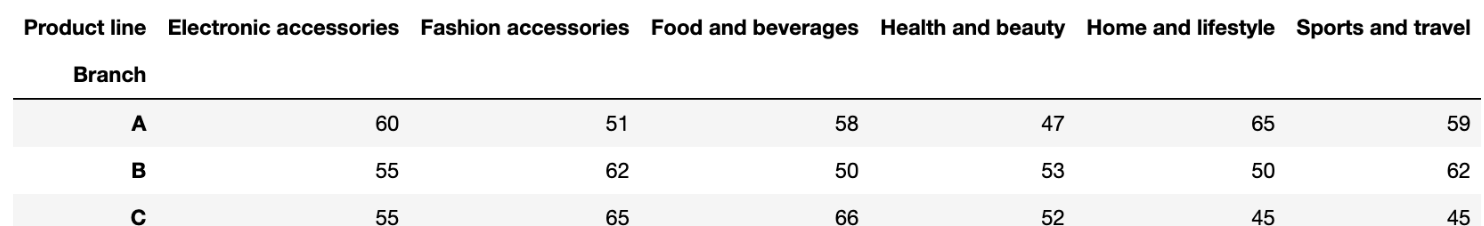


3.2. Викристовуючи змінну `invoices_by_category` дайте відповідь програмно (тобто значення треба не просто знайти очима, а вивести за допомогою коду), в якому філіалі магазину (`Branch`) найбільше інвойсів із покупкою товарів категорії "Електронні аксесуари" (`Electronic accessories`)?


In [19]:
invoice_by_category['Electronic accessories'].idxmax()

'A'

4-6. **Творче завдання на розвиток аналітичного мислення**

Крок 1. Сформулюйте ТРИ питання (гіпотези) до наявних даних, які допомогли б вам зрозуміти, які користувачі що, де та коли найбільше/найменше купують, аби дати на основі цих гіпотез рекомендації бізнесу. Звісно питання мають бути не тими, на які ми вже відповіли в завданнях модулю.

Крок 2. Знайдіть відповіді на свої питання з допомогою функціоналу pandas.

Крок 3. Напишіть, як відповідь на це питання може бути використана для прийняття бізнес рішень.   
   
 Питання можуть бути будь-якої складності, але їх має бути 3. Кожне питання оцінюється як 1 завдання. Без виконання цього завдання ДЗ не приймається. Якщо є питання щодо виконання - пишіть у чат 🙌


### Гіпотези:
1. Payment + Total — чи є зв'язок між способом оплати (Ewallet, Cash, Credit card) і середнім чеком?
2. Customer type + Product line — чи Member купують інші категорії товарів, ніж Normal?
3. День тижня (з Date) + Total — чи є "сильні" та "слабкі" дні тижня по виручці?

## Гіпотеза № 1.


In [23]:
df.groupby('Payment')['Total'].agg('mean')

Payment
Cash           326.181890
Credit card    324.009878
Ewallet        318.820600
Name: Total, dtype: float64

### Результат:
середні чеки по всіх трьох способах оплати дуже близькі (318-326) — суттєвої різниці немає, десь ±2-3%.
### Висновок для бізнесу:
спосіб оплати не впливає на розмір покупки. Тобто немає сенсу, наприклад, стимулювати клієнтів переходити на якийсь конкретний спосіб оплати заради збільшення середнього чека — це не спрацює, бо різниця статистично незначна.

## Гіпотеза № 2.


In [24]:
df.pivot_table(index="Customer type", columns="Product line", values="Invoice ID", aggfunc="count")


Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Customer type,,,,,,
Member,78,86,94,73,83,87
Normal,92,92,80,79,77,79


In [25]:
df.groupby(['Customer type', 'Product line'])['Unit price'].mean()

Customer type  Product line          
Member         Electronic accessories    55.278205
               Fashion accessories       56.776395
               Food and beverages        58.080638
               Health and beauty         56.069041
               Home and lifestyle        55.120241
               Sports and travel         55.604943
Normal         Electronic accessories    52.087717
               Fashion accessories       57.506304
               Food and beverages        53.574500
               Health and beauty         53.732152
               Home and lifestyle        55.528961
               Sports and travel         58.522152
Name: Unit price, dtype: float64

### Результат:
### Member 
найбільше купують Food and beverages (94) та Sports and travel (87)
### Normal 
найбільше купують Electronic accessories (92) та Fashion accessories (92) — рівно порівну
### Найбільша різниця між типами клієнтів: 
Food and beverages (+14 на користь Member) та Electronic accessories (+14 на користь Normal). При цьому загальна кількість покупок в обох групах практично однакова (501 проти 499) — різниця саме в тому, що купують, а не скільки.
Додатково перевірили гіпотезу про причину: чи не пояснюється це постійною знижкою для Member (порівняли середню Unit price по категоріях між групами) — підтвердження не знайшли, ціни між групами відрізняються без чіткого патерну.
### Рекомендація для бізнесу:

1. Таргетувати рекомендації/розсилки відповідно до вже наявної схильності: Member → Food & beverages, Sports & travel; Normal → Electronics, Fashion
2. Використовувати момент покупки електроніки Normal-клієнтом як точку пропозиції Member-статусу (високий чек + нема ще членства)
3. Точну причину різниці в структурі покупок (звички, промо, психологія) дані не пояснюють — для глибших рішень потрібні додаткові дані (історія промо, дата реєстрації в програмі лояльності)

## Гіпотеза № 3.


In [26]:
df['Date'] = pd.to_datetime(df['Date'])



In [27]:
df['day_of_week'] = df['Date'].dt.day_name()

In [28]:
df.groupby('day_of_week')['Total'].sum()

day_of_week
Friday       43926.3405
Monday       37899.0780
Saturday     56120.8095
Sunday       44457.8925
Thursday     45349.2480
Tuesday      51482.2455
Wednesday    43731.1350
Name: Total, dtype: float64

In [29]:
df.groupby('day_of_week')['Total'].sum().idxmax()

'Saturday'

Найприбутковіший день — 
### Saturday (56 120.81) 
найслабший — 
### Monday (37 899.08). 
Різниця між ними — майже 48%.

### Висновок для бізнесу:
Субота — явний пік виручки (як і очікувано для роздрібної торгівлі, вихідний день). Понеділок помітно провисає — майже вдвічі менше за суботу.

### Практичні кроки:
1. Персонал: переконатись, що в суботу достатньо працівників на зміні, щоб впоратись з навантаженням і не втрачати продажі через черги/нестачу консультантів.
2. Промо-акції в слабкі дні: запустити знижки/спецпропозиції саме в понеділок-середу, щоб вирівняти потік клієнтів протягом тижня, а не концентрувати всю виручку на вихідних.
3. Закупівлі/поповнення складу: плануючи поставки товару, враховувати, що субота вимагає найбільшого запасу.